# 5 — Stage 2: which words are the drug and which are the effect?

Stage 1 answered *does this sentence report an adverse drug event?* Stage 2 answers the
follow-up: **which exact words?**

> A case of toxic hepatitis caused by methotrexate.
>            └─── EFFECT ───┘         └── DRUG ──┘

This is **sequence labelling**: one decision per word, not one per sentence. Three models
were trained, and the interesting comparison between them is not which scores highest — it
is what happens when you let the model see its *own previous decision*.

In [1]:
import sys, json, textwrap
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 90)
print("project root:", ROOT)

project root: E:\CSE\NLP Project


---

## 5.1 The labels

Stage 2 trains only on sentences that really are ADEs — 2,990 of them — because those are
the only ones the corpus annotates with spans. Each sentence's character spans become one
BIO tag per word (notebook 2 covers the conversion; here is what comes out).

In [2]:
from src.bio import to_bio, TAGS, count_illegal_transitions
from src.vocab import is_indexable

test = pd.read_parquet(ROOT / "data" / "splits" / "stage2_test.parquet")
print(f"{len(test)} test sentences, {int(test['n_spans'].sum()):,} annotated spans")
print(f"tag inventory: {TAGS}\n")

row = test.iloc[0]
tokens, tags = to_bio(row["text"], [tuple(s) for s in json.loads(row["spans"])])
print(row["text"], "\n")
print("  " + "  ".join(f"{t:>14s}" for t in tokens))
print("  " + "  ".join(f"{t:>14s}" for t in tags))

640 test sentences, 1,636 annotated spans
tag inventory: ('O', 'B-DRUG', 'I-DRUG', 'B-EFFECT', 'I-EFFECT')

2-CdA induces lymphocytopenia, which may explain the improvement in this patient's psoriasis. 

           2-cda         induces  lymphocytopenia               ,           which             may         explain             the     improvement              in            this       patient's       psoriasis               .
          B-DRUG               O        B-EFFECT               O               O               O               O               O               O               O               O               O               O               O


That is the training signal. The model sees the words and has to produce the tags.

### Preparing the whole split

The same conversion over all 640 test sentences gives the gold answers everything below is
scored against. Punctuation is dropped — it is not in the shared vocabulary, and the tags
have to be dropped **in lockstep** with it or every sentence containing a comma is shifted
by one from that comma onward.

In [3]:
def prepare(frame):
    """Sentences -> (words, gold tags), punctuation dropped from both together."""
    words, gold = [], []
    for _, r in frame.iterrows():
        tokens, tags = to_bio(r["text"], [tuple(s) for s in json.loads(r["spans"])],
                              strict=False)
        kept = [(t, g) for t, g in zip(tokens, tags) if is_indexable(t)]
        words.append([t for t, _ in kept])
        gold.append([g for _, g in kept])
    return words, gold

words, gold = prepare(test)
print(f"{len(words)} sentences, {sum(len(w) for w in words):,} words")
print(f"gold entities: {sum(1 for tags in gold for t in tags if t.startswith('B-')):,}")

# A sanity check that matters for section 5.3: the gold data contains no
# structurally impossible tag sequence at all.
print(f"illegal transitions in the GOLD tags: "
      f"{sum(count_illegal_transitions(g) for g in gold)}")

640 sentences, 11,452 words
gold entities: 1,612
illegal transitions in the GOLD tags: 0


---

## 5.2 The three models

| Run | Model | The one thing that makes it different |
|---|---|---|
| 9 | BiLSTM + softmax | decides each word independently |
| 10 | BiLSTM + **CRF** | decides the whole sequence jointly |
| 11 | BiomedBERT | transformer, pretrained on PubMed |

Runs 9 and 10 are the **same class with one flag flipped**. Same embedding matrix (E3),
same hidden size, same learning rate, same seed. `use_crf` is the only difference, which
is what makes the comparison in 5.3 a clean measurement.

```
word ids -> Embedding (E3) -> BiLSTM -> linear -> 5 scores per word
                                                       |
                                     run 9:  softmax, argmax each word separately
                                     run 10: CRF, Viterbi over the whole sentence
```

In [4]:
import numpy as np
from src.models import BiLSTMTagger

matrix = np.load(ROOT / "models" / "emb_matrices" / "E3.npy")
softmax_tagger = BiLSTMTagger(matrix, use_crf=False)
crf_tagger = BiLSTMTagger(matrix, use_crf=True)

print(f"run 9  (softmax): {softmax_tagger.trainable_parameters():,} trainable parameters")
print(f"run 10 (CRF)    : {crf_tagger.trainable_parameters():,} trainable parameters")
print(f"the CRF adds    : {crf_tagger.trainable_parameters() - softmax_tagger.trainable_parameters()} "
      f"- a {len(TAGS)}x{len(TAGS)} transition matrix, plus start and end scores")

run 9  (softmax): 1,145,349 trainable parameters
run 10 (CRF)    : 1,145,384 trainable parameters
the CRF adds    : 35 - a 5x5 transition matrix, plus start and end scores


**35 extra parameters.** That is the entire CRF: a score for every tag-to-tag transition,
plus a start and end score. Section 5.3 shows what they buy.

### Training

```python
model = BiLSTMTagger(np.load("models/emb_matrices/E3.npy"), use_crf=args.crf)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):
    for ids, lengths, tags in train_loader:
        loss = model(ids, lengths, tags)     # cross-entropy, or -log P(sequence) with CRF
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    dev_f1 = entity_f1(model.decode(dev_ids, dev_lengths), dev_gold)
    ...                                      # keep the best epoch, stop after 4 bad ones
```

The only change between run 9 and run 10 is `--crf`. Note the loss line: with a CRF the
model computes its own loss inside `forward`, because the probability of a tag *sequence*
is not the product of independent per-word probabilities.

Run 11 is the Hugging Face equivalent:

```python
model = AutoModelForTokenClassification.from_pretrained(
    "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract", num_labels=len(TAGS))
```

Fine-tuned for 5 epochs at learning rate 3e-5, max length 192. A transformer splits words
into subwords, so at scoring time each word's tag is read from its **first** subword — that
is how run 11 stays comparable with the word-level BiLSTMs.

---

## 5.3 Results, computed here

Nothing below is retrained. The three checkpoints are loaded from `models/stage2/`, run over
the test split on this laptop's CPU, and scored.

**Entity-F1, not word accuracy.** Getting 9 words out of 10 right sounds good until the one
you missed was half the drug name — an entity with the wrong boundary is simply wrong, not
90% right. So scoring is *strict*: a predicted entity counts only if its label **and** both
its boundaries match a gold entity exactly.

In [5]:
import time
from src.bio import entity_f1
from src.pipeline import load_tagger

results = {}
for run, label in [("9", "BiLSTM softmax"), ("10", "BiLSTM + CRF"), ("11", "BiomedBERT")]:
    t0 = time.perf_counter()
    predicted = load_tagger(run).tag(words)
    scores = entity_f1(gold, predicted)
    results[run] = {
        "model": label,
        "strict entity-F1": round(scores["f1"], 4),
        "precision": round(scores["precision"], 3),
        "recall": round(scores["recall"], 3),
        "entities found": scores["predicted_entities"],
        "illegal transitions": sum(count_illegal_transitions(p) for p in predicted),
    }
    print(f"run {run:>2s} {label:16s} scored in {time.perf_counter() - t0:5.1f}s")

pd.DataFrame(results).T.rename_axis("run")

run  9 BiLSTM softmax   scored in   0.4s


run 10 BiLSTM + CRF     scored in   0.5s


E:\CSE\NLP Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run 11 BiomedBERT       scored in  42.6s


,model,strict entity-F1,precision,recall,entities found,illegal transitions
run,,,,,,
9,BiLSTM softmax,0.8124,0.818,0.807,1591,82
10,BiLSTM + CRF,0.8308,0.854,0.809,1527,5
11,BiomedBERT,0.9052,0.898,0.913,1638,32


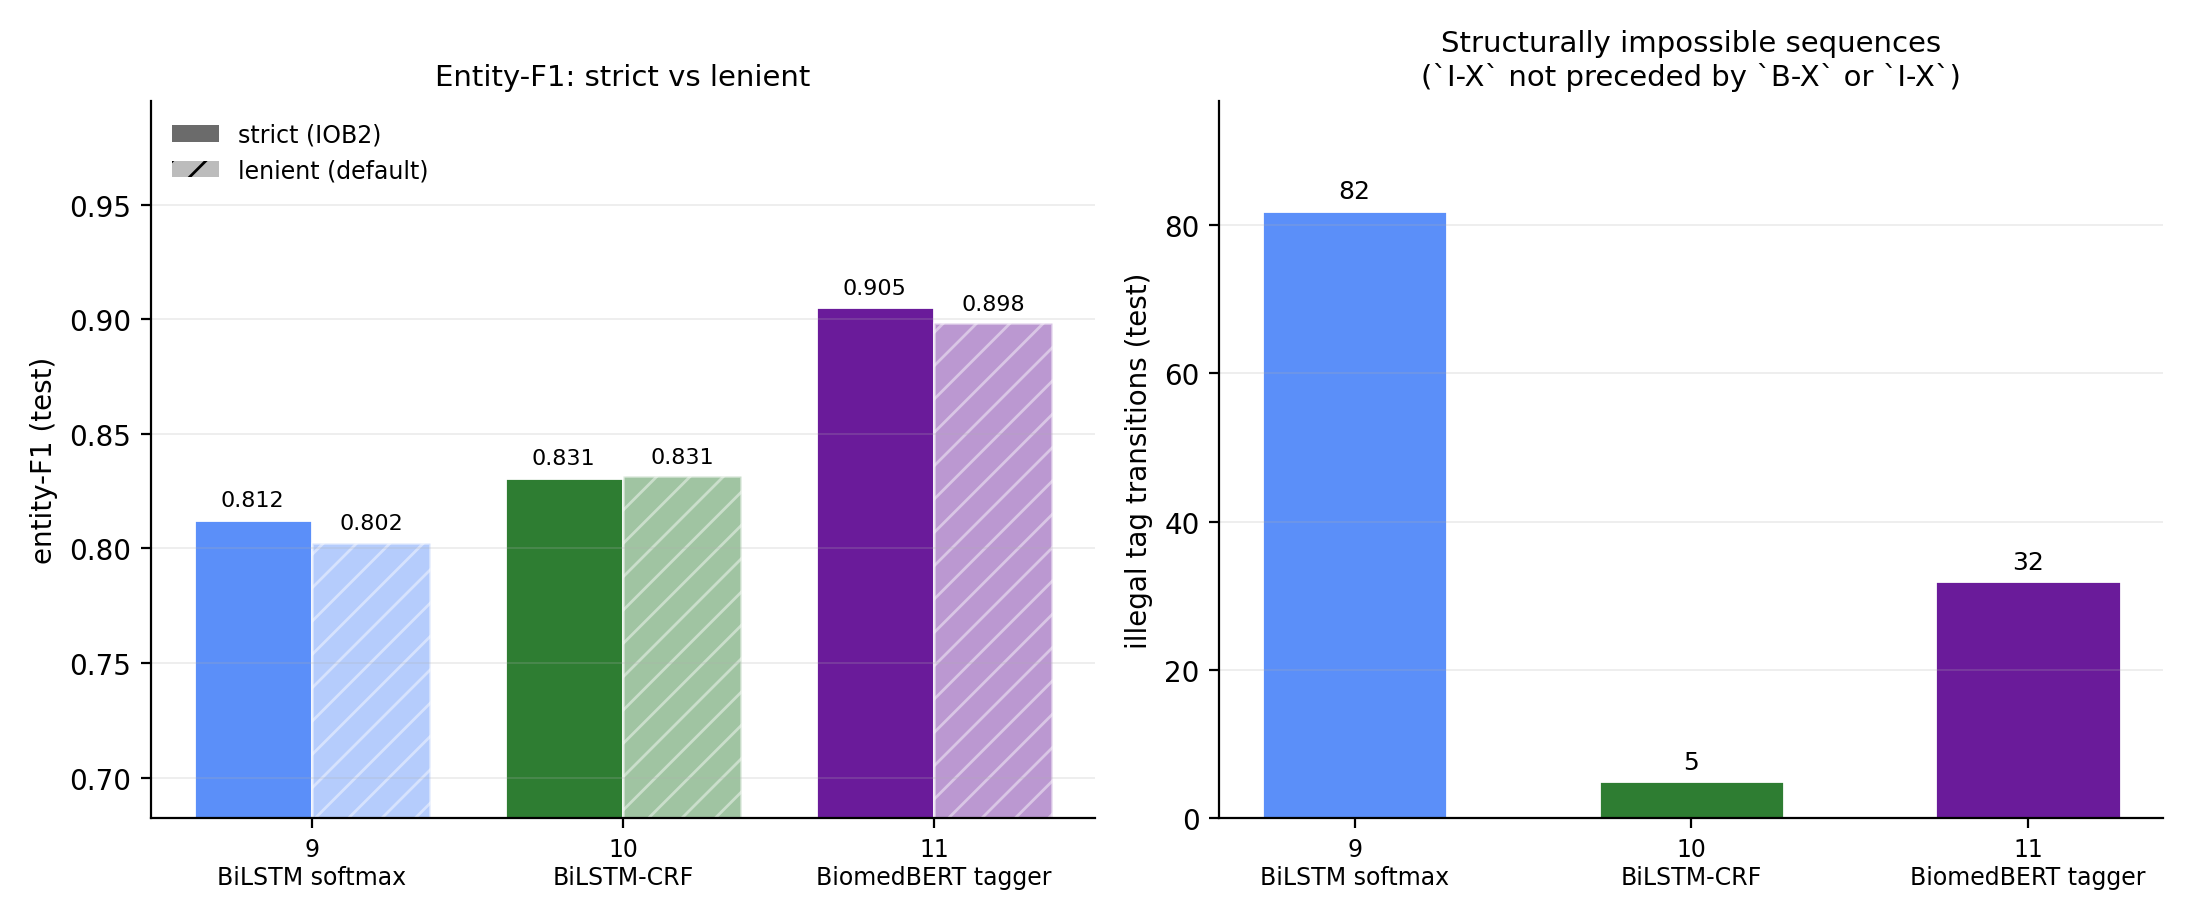

In [6]:
from IPython.display import Image
Image(filename=str(ROOT / "results" / "figures" / "stage2_crf.png"))

### What the CRF is for

Look at the **illegal transitions** column: **82 → 5**, a 94% reduction.

An "illegal transition" is an `I-DRUG` that does not follow a `B-DRUG` or another
`I-DRUG` — a sequence that cannot describe any entity. The gold data contains exactly
**zero** of them (checked in 5.1). A per-word softmax emits them freely, because it decides
each position on its own and nothing in its objective ever mentions the previous tag.

Be precise about the mechanism, because it is easy to overclaim:

> `pytorch-crf` **forbids nothing**. Its transition matrix starts uniform and every
> transition stays reachable. Because the gold sequences contain no illegal transition,
> training drives those transition scores down until Viterbi rarely picks a path through
> them. The constraint is **learned from the data, not imposed by the architecture**.

That is exactly what the remaining 5 are: a path through a heavily penalised transition is
still chosen when the word-level evidence is strong enough. So the honest claim is "a large
reduction", not "a guarantee".

Entity-F1 also moved, +0.018, mostly through **precision** (0.818 → 0.854) rather than
recall. That fits: the CRF is not finding more entities, it is emitting fewer malformed
ones.

The cost is training time — 19 seconds to 94 seconds, about 5x — because the forward
algorithm and Viterbi decoding are sequential over the sentence.

### Run 11 and the ceiling

BiomedBERT reaches **0.9052**, well clear of both BiLSTMs, and it does that *without* a CRF
— it still emits 32 illegal transitions. Self-attention gives every position a view of the
whole sentence, so it learns most of the same structure implicitly, just not all of it.

It is also the slowest by far on CPU, which is why the demo in notebook 6 offers both and
defaults to the BiLSTM pair.

---

## 5.4 Seeing it tag

Strict scoring is unforgiving, so it is worth looking at what the output actually is.

In [7]:
from src.bio import strict_entities

tagger = load_tagger("10")
sentences = [
    "A case of toxic hepatitis caused by methotrexate and etretinate is presented.",
    "Severe rhabdomyolysis developed after starting simvastatin.",
    # A real test sentence, and then the same content compressed into a shorter one.
    "A 55-year-old woman presented an episode of acute urticaria and labial angioedema "
    "60 minutes after ingesting 500 mg of cloxacillin for a skin abscess.",
    "Acute urticaria and labial angioedema followed ingestion of cloxacillin.",
]

for sentence in sentences:
    from src.pipeline import words_of
    tokens = words_of(sentence)
    tags = tagger.tag([tokens])[0]
    found = [(label, " ".join(tokens[a:b])) for a, b, label in strict_entities(tags)]
    print(sentence)
    for label, text in found:
        print(f"    {label:7s} {text}")
    print()

A case of toxic hepatitis caused by methotrexate and etretinate is presented.
    EFFECT  toxic hepatitis
    DRUG    methotrexate
    DRUG    etretinate

Severe rhabdomyolysis developed after starting simvastatin.
    EFFECT  severe rhabdomyolysis
    DRUG    simvastatin

A 55-year-old woman presented an episode of acute urticaria and labial angioedema 60 minutes after ingesting 500 mg of cloxacillin for a skin abscess.
    EFFECT  acute urticaria
    EFFECT  labial angioedema
    DRUG    cloxacillin

Acute urticaria and labial angioedema followed ingestion of cloxacillin.
    EFFECT  acute urticaria
    DRUG    labial
    EFFECT  angioedema
    DRUG    cloxacillin



The first two show the model is not pattern-matching on word order: the effect comes after
the drug in one and before it in the other, and both are read correctly.

**The last two are the same content, and the model gets one of them wrong.** In the real
test sentence it reads `labial angioedema` as a single EFFECT. In the compressed
paraphrase it splits that phrase, tagging `labial` as a DRUG — which is not even the right
*kind* of thing. Nothing about the phrase changed; only the sentence around it did.

That is worth seeing before the scores in the next notebook. Strict entity-F1 of 0.83
means roughly one entity in six is wrong like this, and the failures are not evenly spread
— notebook 6 measures where they cluster.

---

## What this notebook produced

| Artefact | Contents |
|---|---|
| `models/stage2/run9_softmax/`, `run10_crf/`, `run11_biomedbert/` | three trained taggers |
| `results/figures/stage2_crf.png` | the CRF ablation chart |

**Key numbers:** strict entity-F1 0.8124 (softmax) → 0.8308 (CRF) → 0.9052 (BiomedBERT);
illegal transitions 82 → 5 with the CRF.

Everything so far has scored Stage 2 on **gold** ADE sentences, as though Stage 1 were
perfect. **Next:** [6 — The pipeline](06_pipeline_and_demo.ipynb), where the two stages are
chained and the cost of that assumption is measured.